**LIBRERÍAS**

In [1]:
import pandas as pd
import sklearn as sk
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
import zipfile
import os
import torch.optim as optim
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve)

**DESCARGA DEL DATASET**

In [2]:
url = 'https://drive.google.com/file/d/1CZOPvXzpA48GC2WVsmA5hZvyQugDQ6sQ/view?usp=drive_link'
zip_filename = 'dataset.zip'
extract_dir = './dataset_extraido'

gdown.download(url, zip_filename, quiet=False)

if os.path.exists(zip_filename):
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f"Archivo descomprimido con éxito en: {extract_dir}")

ruta_csv = os.path.join('./dataset_extraido/healthcare-dataset-stroke-data.csv')
df = pd.read_csv(ruta_csv)
df_copia = df.copy() # copia de resguardo del df original

Downloading...
From: https://drive.google.com/uc?id=1CZOPvXzpA48GC2WVsmA5hZvyQugDQ6sQ
To: c:\Users\fjm25\Desktop\Facundo\TUIA\AA2\TP1\dataset.zip
100%|██████████| 69.0k/69.0k [00:00<00:00, 2.02MB/s]

Archivo descomprimido con éxito en: ./dataset_extraido


**EDA**

| Columna | Tipo de dato | Descripción | Valores / Rango |
| :--- | :--- | :--- | :--- |
| **id** | Entero (ID) | Identificador único del paciente | Número entero de identificación |
| **gender** | Categórico | Género del paciente | `"Male"`, `"Female"`, `"Other"` |
| **age** | Numérico (Continuo) | Edad del paciente en años | Número flotante o entero |
| **hypertension** | Binario (Nominal) | Presencia de hipertensión arterial previa | `0` = No, `1` = Sí |
| **heart_disease** | Binario (Nominal) | Presencia de enfermedad cardíaca previa | `0` = No, `1` = Sí |
| **ever_married** | Categórico | Indica si el paciente ha estado casado alguna vez | `"Yes"`, `"No"` |
| **work_type** | Categórico | Tipo de ocupación o relación laboral | `"Private"`, `"Self-employed"`, `"Govt_job"`, `"children"`, `"Never_worked"` |
| **Residence_type** | Categórico | Tipo de zona de residencia | `"Urban"`, `"Rural"` |
| **avg_glucose_level** | Numérico (Continuo) | Nivel promedio de glucosa en sangre (mg/dL) | Número flotante |
| **bmi** | Numérico (Continuo) | Índice de masa corporal ($\text{kg/m}^2$) | Número flotante (contiene valores nulos / `"N/A"`) |
| **smoking_status** | Categórico | Estado actual o histórico de consumo de tabaco | `"formerly smoked"`, `"never smoked"`, `"smokes"`, `"Unknown"` |
| **stroke** | Binario (Target) | Indica si el paciente sufrió un accidente cerebrovascular | `0` = No, `1` = Sí |

In [3]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [5]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [6]:
total_duplicados = df.duplicated().sum()
print(f"Total de filas completas duplicadas: {total_duplicados}")

ids_duplicados = df.duplicated(subset=['id']).sum()
print(f"Total de IDs duplicados: {ids_duplicados}")

Total de filas completas duplicadas: 0
Total de IDs duplicados: 0


In [7]:
print(pd.DataFrame({'Total_Nulos': df.isnull().sum(),'Porcentaje_%': (df.isnull().sum() / len(df)) * 100}))

                   Total_Nulos  Porcentaje_%
id                           0      0.000000
gender                       0      0.000000
age                          0      0.000000
hypertension                 0      0.000000
heart_disease                0      0.000000
ever_married                 0      0.000000
work_type                    0      0.000000
Residence_type               0      0.000000
avg_glucose_level            0      0.000000
bmi                        201      3.933464
smoking_status               0      0.000000
stroke                       0      0.000000


**DESBALANCEO DE LA VARIABLE OBJETIVO**

In [8]:
df.value_counts('stroke')

stroke
0    4861
1     249
Name: count, dtype: int64

**SPLIT**

In [9]:
X = df.drop(columns=['stroke', 'id'])
y = df['stroke']

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y)


X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, 
    test_size=0.25, 
    random_state=42, 
    stratify=y_train_val)

print(f"Dimensiones de X_train: {X_train.shape} ({len(X_train)/len(df):.0%})")
print(f"Dimensiones de X_val:   {X_val.shape} ({len(X_val)/len(df):.0%})")
print(f"Dimensiones de X_test:  {X_test.shape} ({len(X_test)/len(df):.0%})")

print("\n--- Distribución de 'stroke' (Proporción %) ---")
print(f"Original: \n{y.value_counts(normalize=True).round(4)}")
print(f"Train:    \n{y_train.value_counts(normalize=True).round(4)}")
print(f"Val:      \n{y_val.value_counts(normalize=True).round(4)}")
print(f"Test:     \n{y_test.value_counts(normalize=True).round(4)}")

Dimensiones de X_train: (3066, 10) (60%)
Dimensiones de X_val:   (1022, 10) (20%)
Dimensiones de X_test:  (1022, 10) (20%)

--- Distribución de 'stroke' (Proporción %) ---
Original: 
stroke
0    0.9513
1    0.0487
Name: proportion, dtype: float64
Train:    
stroke
0    0.9514
1    0.0486
Name: proportion, dtype: float64
Val:      
stroke
0    0.9511
1    0.0489
Name: proportion, dtype: float64
Test:     
stroke
0    0.9511
1    0.0489
Name: proportion, dtype: float64


In [10]:
# VER 


# borrado bmi
bim_filas_incompletas = X_train[X_train['bmi'].isna()].index

X_train = X_train.drop(index=bim_filas_incompletas)

y_train = y_train.drop(index=bim_filas_incompletas)


#  IMPUTACIÓN CON MEDIANA EN TEST Y VAL
bmi_median = X_train['bmi'].median()

X_val['bmi'] = X_val['bmi'].fillna(bmi_median)
X_test['bmi'] = X_test['bmi'].fillna(bmi_median)

#alternativa - imputacion con mediana en vez de borrado
# X_train['bmi'] = X_train['bmi'].fillna(bmi_median)


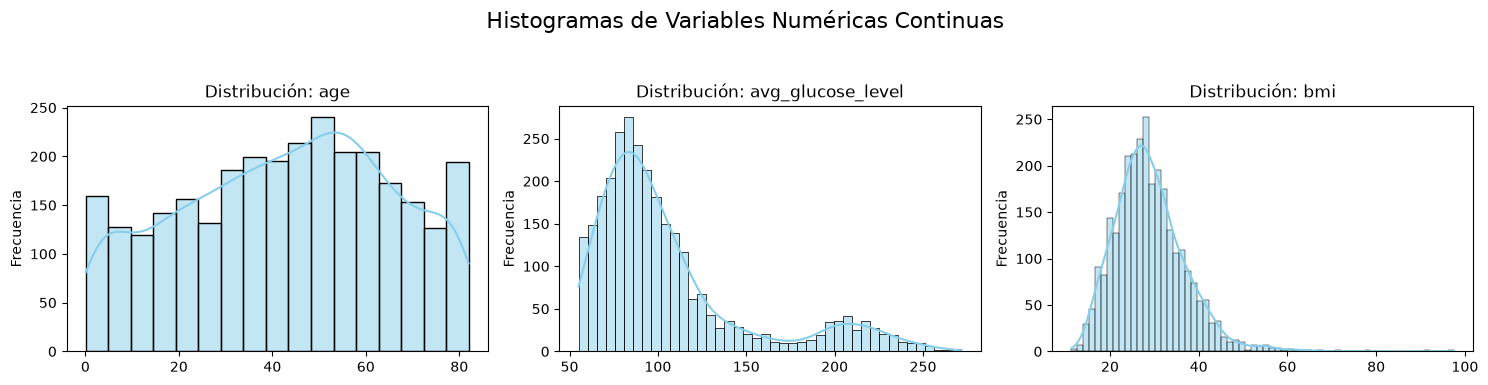

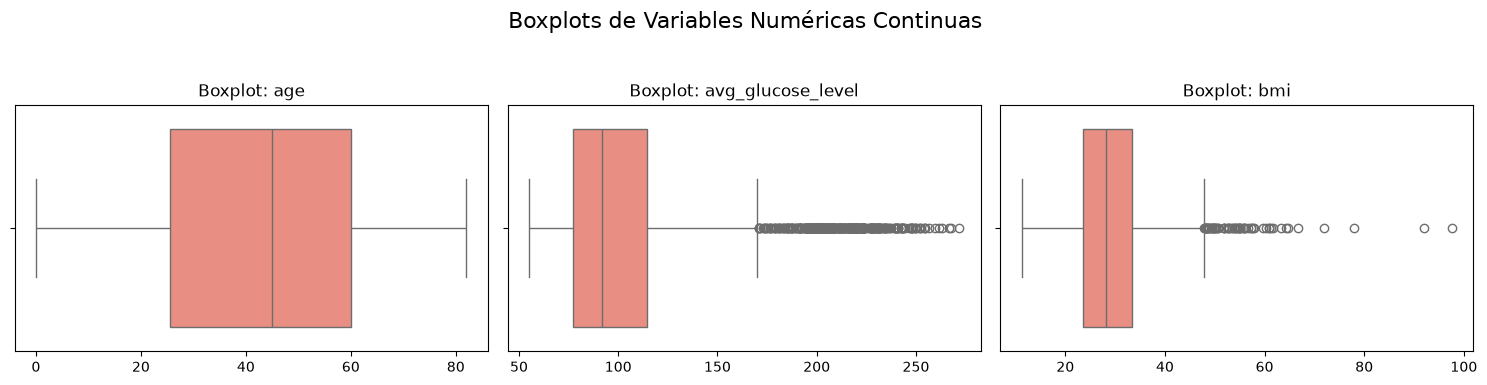

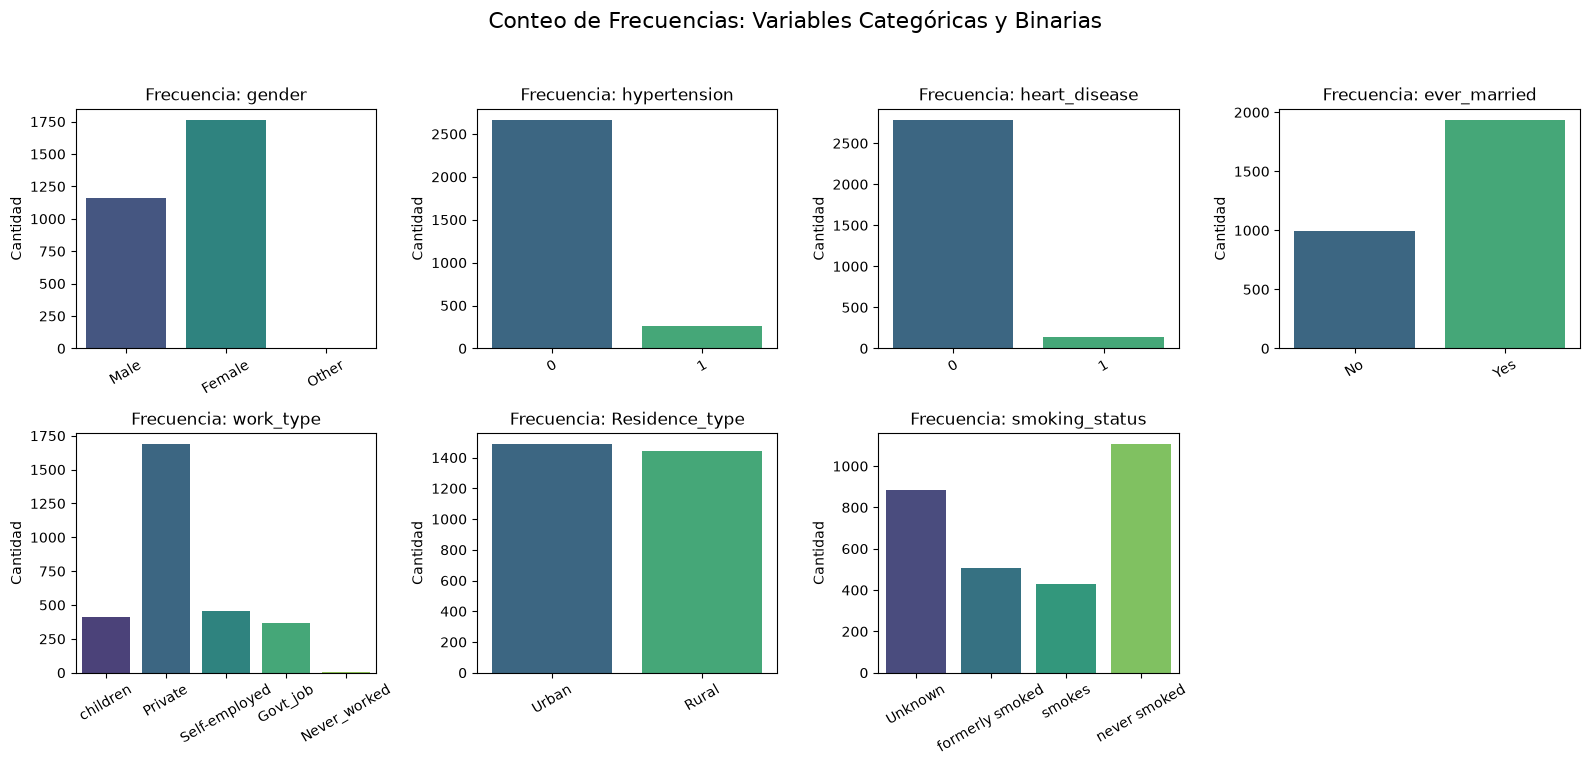

In [11]:
vars_numericas = ['age', 'avg_glucose_level', 'bmi']
vars_categoricas = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

cols = 3
rows = int(np.ceil(len(vars_numericas) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 4))
fig.suptitle('Histogramas de Variables Numéricas Continuas', fontsize=16)

axes_flat = np.array(axes).flatten()

for i, col in enumerate(vars_numericas):
    sns.histplot(data=X_train, x=col, kde=True, ax=axes_flat[i], color='skyblue')
    axes_flat[i].set_title(f'Distribución: {col}')
    axes_flat[i].set_xlabel('')
    axes_flat[i].set_ylabel('Frecuencia')

for j in range(len(vars_numericas), len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

fig, axes = plt.subplots(rows, cols, figsize=(15, 4))
fig.suptitle('Boxplots de Variables Numéricas Continuas', fontsize=16)

axes_flat = np.array(axes).flatten()

for i, col in enumerate(vars_numericas):
    sns.boxplot(data=X_train, x=col, ax=axes_flat[i], color='salmon')
    axes_flat[i].set_title(f'Boxplot: {col}')
    axes_flat[i].set_xlabel('')

for j in range(len(vars_numericas), len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

cols_cat = 4
rows_cat = int(np.ceil(len(vars_categoricas) / cols_cat))

fig, axes = plt.subplots(rows_cat, cols_cat, figsize=(16, 8))
fig.suptitle('Conteo de Frecuencias: Variables Categóricas y Binarias', fontsize=16)

axes_flat_cat = np.array(axes).flatten()

for i, col in enumerate(vars_categoricas):
    ax = axes_flat_cat[i]
    sns.countplot(data=X_train, x=col, ax=ax, palette='viridis', hue=col, legend=False)
    ax.set_title(f'Frecuencia: {col}')
    ax.set_xlabel('')
    ax.set_ylabel('Cantidad')
    ax.tick_params(axis='x', rotation=30)

for j in range(len(vars_categoricas), len(axes_flat_cat)):
    fig.delaxes(axes_flat_cat[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

C:\Users\fjm25\AppData\Local\Temp\ipykernel_21824\4096374514.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=X_train.assign(stroke=y_train), x='stroke', y='avg_glucose_level', ax=axes[0], palette='Set2')
C:\Users\fjm25\AppData\Local\Temp\ipykernel_21824\4096374514.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=X_train.assign(stroke=y_train), x='stroke', y='bmi', ax=axes[1], palette='Set2')


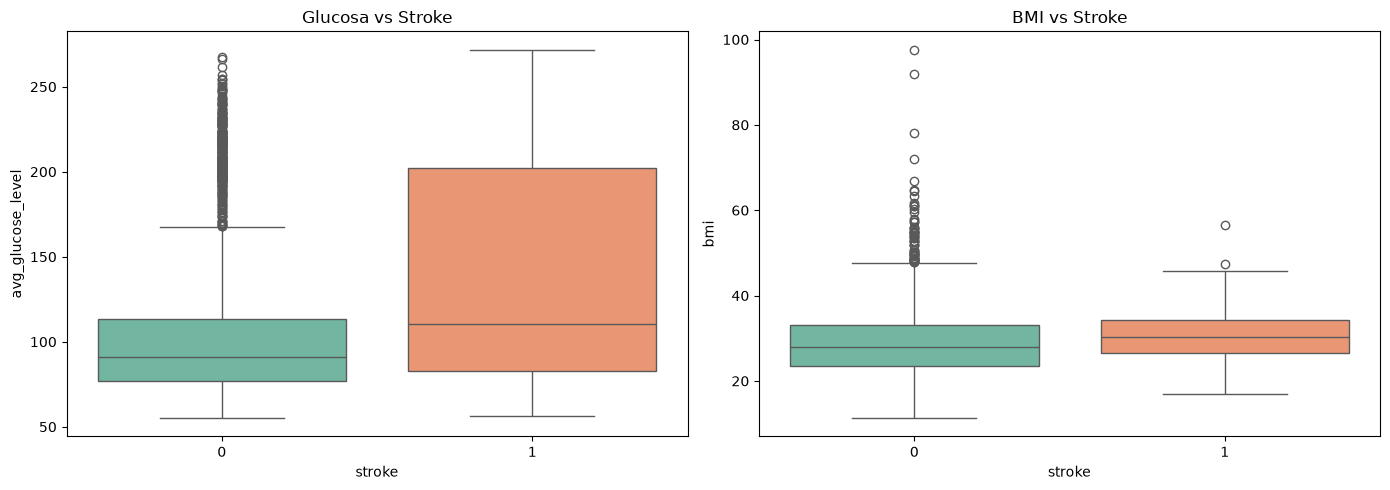

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=X_train.assign(stroke=y_train), x='stroke', y='avg_glucose_level', ax=axes[0], palette='Set2')
axes[0].set_title('Glucosa vs Stroke')

sns.boxplot(data=X_train.assign(stroke=y_train), x='stroke', y='bmi', ax=axes[1], palette='Set2')
axes[1].set_title('BMI vs Stroke')

plt.tight_layout()
plt.show()

C:\Users\fjm25\AppData\Local\Temp\ipykernel_21824\1524402408.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_corr.select_dtypes(include=['object', 'category']).columns:


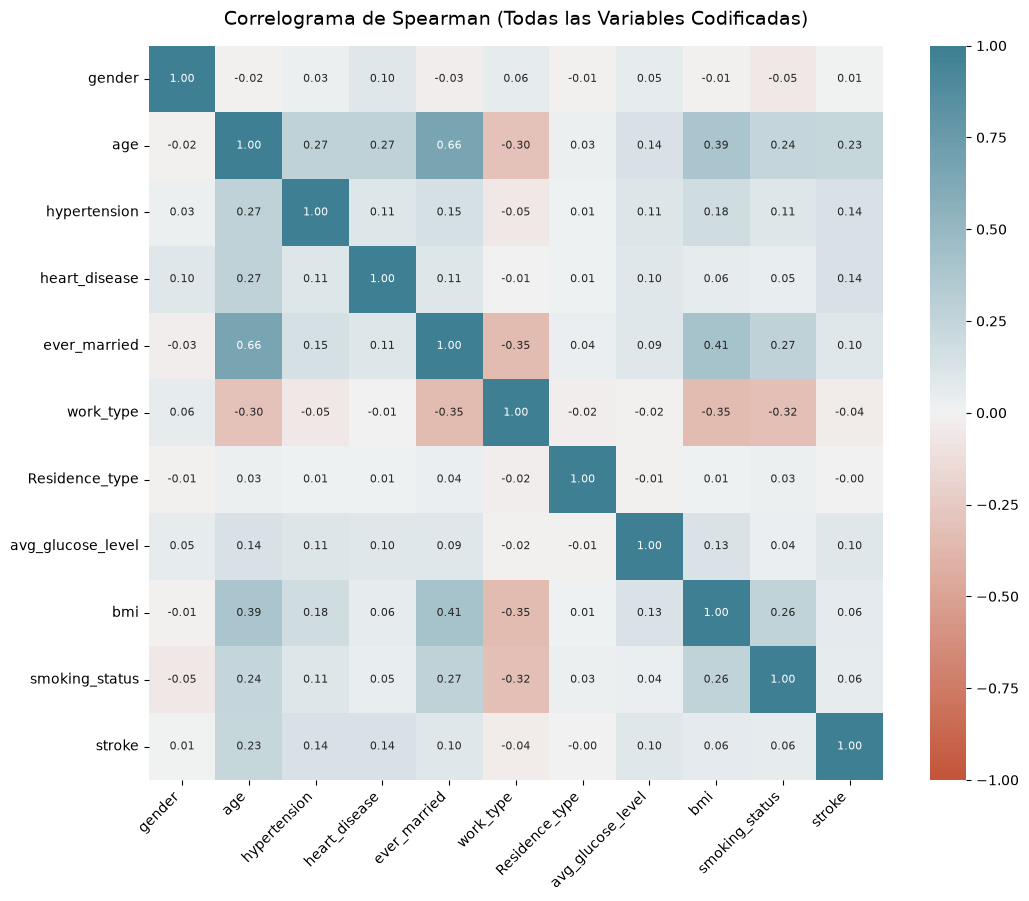

In [13]:
df_train = pd.concat([X_train, y_train], axis=1)
df_corr = df_train.copy()

for col in df_corr.select_dtypes(include=['object', 'category']).columns:
    df_corr[col] = df_corr[col].astype('category').cat.codes

if 'id' in df_corr.columns:
    df_corr = df_corr.drop(columns=['id'])

corr = df_corr.corr(method='spearman')

plt.figure(figsize=(11, 9))
ax = sns.heatmap(
    corr, vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True, annot=True, fmt=".2f",
    annot_kws={'size': 8}
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.title('Correlograma de Spearman (Todas las Variables Codificadas)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

**PREPROCESAMIENTO**

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numericas", StandardScaler(), vars_numericas),
        ("categoricas", OneHotEncoder(drop='first', sparse_output=False), vars_categoricas)
    ])


X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

print(f"Forma de X_train procesado: {X_train_prep.shape}")
print(f"Forma de X_val procesado:   {X_val_prep.shape}")
print(f"Forma de X_test procesado:  {X_test_prep.shape}")

Forma de X_train procesado: (2927, 16)
Forma de X_val procesado:   (1022, 16)
Forma de X_test procesado:  (1022, 16)


**RESAMPLING POR DESBALANCEO - SMOTE**

In [15]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_prep, y_train)

num_features = X_train_smote.shape[1]

print("--- Distribución de 'stroke' antes de SMOTE ---")
print(y_train.value_counts())

print("\n--- Distribución de 'stroke' después de SMOTE ---")
print(pd.Series(y_train_smote).value_counts())

print(f"\nDimensiones finales de X_train_smote: {X_train_smote.shape}")

--- Distribución de 'stroke' antes de SMOTE ---
stroke
0    2808
1     119
Name: count, dtype: int64

--- Distribución de 'stroke' después de SMOTE ---
stroke
0    2808
1    2808
Name: count, dtype: int64

Dimensiones finales de X_train_smote: (5616, 16)


In [16]:
"""class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out) 
        return out

model = MLP(input_dim=num_features, hidden_dim=64)
criterion = nn.BCEWithLogitsLoss() # Sin pos_weight porque SMOTE ya balanceó
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)


X_train_tensor = torch.tensor(
    X_train_smote.values if hasattr(X_train_smote, 'values') else X_train_smote, 
    dtype=torch.float32
)
y_train_tensor = torch.tensor(
    y_train_smote.values if hasattr(y_train_smote, 'values') else np.array(y_train_smote), 
    dtype=torch.float32
).view(-1, 1) 

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

model.train() 
epochs = 50
best_loss = float('inf')

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        logits = model(batch_X)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_X.size(0)
    
    epoch_loss = running_loss / len(train_loader.dataset)
    if (epoch + 1) % 10 == 0:
        print(f"Época [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f}")"""

'class MLP(nn.Module):\n    def __init__(self, input_dim, hidden_dim):\n        super(MLP, self).__init__()\n        self.fc1 = nn.Linear(input_dim, hidden_dim)\n        self.relu = nn.ReLU()\n        self.fc2 = nn.Linear(hidden_dim, 1)\n\n    def forward(self, x):\n        out = self.fc1(x)\n        out = self.relu(out)\n        out = self.fc2(out) \n        return out\n\nmodel = MLP(input_dim=num_features, hidden_dim=64)\ncriterion = nn.BCEWithLogitsLoss() # Sin pos_weight porque SMOTE ya balanceó\noptimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)\n\n\nX_train_tensor = torch.tensor(\n    X_train_smote.values if hasattr(X_train_smote, \'values\') else X_train_smote, \n    dtype=torch.float32\n)\ny_train_tensor = torch.tensor(\n    y_train_smote.values if hasattr(y_train_smote, \'values\') else np.array(y_train_smote), \n    dtype=torch.float32\n).view(-1, 1) \n\ntrain_dataset = TensorDataset(X_train_tensor, y_train_tensor)\ntrain_loader = DataLoader(train_dataset

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_rate)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out

X_train_np = X_train_smote.values if hasattr(X_train_smote, 'values') else X_train_smote
y_train_np = y_train_smote.values if hasattr(y_train_smote, 'values') else np.array(y_train_smote)

X_train_tensor = torch.tensor(X_train_np, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32).view(-1, 1)

dataset = TensorDataset(X_train_tensor, y_train_tensor)

train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

model = MLP(input_dim=num_features, hidden_dim=64, dropout_rate=0.2)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

epochs = 100
print("Entrenamiento red neuronal con Mini-Batches")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        logits = model(batch_X)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * batch_X.size(0)
    
    epoch_loss = running_loss / len(train_loader.dataset)
    
    if (epoch + 1) % 10 == 0:
        print(f"Época [{epoch+1}/{epochs}] - Loss Promedio: {epoch_loss:.4f}")

Entrenamiento red neuronal con Mini-Batches
Época [10/100] - Loss Promedio: 0.5259
Época [20/100] - Loss Promedio: 0.4558
Época [30/100] - Loss Promedio: 0.4349
Época [40/100] - Loss Promedio: 0.4236
Época [50/100] - Loss Promedio: 0.4179
Época [60/100] - Loss Promedio: 0.4087
Época [70/100] - Loss Promedio: 0.4015
Época [80/100] - Loss Promedio: 0.3969
Época [90/100] - Loss Promedio: 0.3891
Época [100/100] - Loss Promedio: 0.3854


       MÉTRICAS DE EVALUACIÓN (TEST)   
Recall (Sensibilidad) : 0.7600  
F1-Score               : 0.2734
AUC-ROC                : 0.8446
Precisión              : 0.1667
Accuracy (Ojo!)        : 0.8023

Clasificación por Clase:
               precision    recall  f1-score   support

No Stroke (0)       0.98      0.80      0.89       972
   Stroke (1)       0.17      0.76      0.27        50

     accuracy                           0.80      1022
    macro avg       0.58      0.78      0.58      1022
 weighted avg       0.94      0.80      0.86      1022



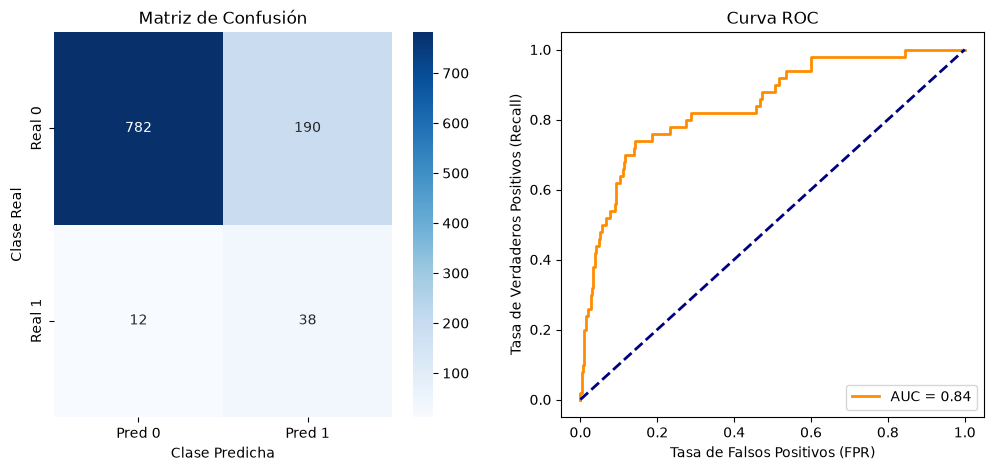

In [58]:
model.eval()

X_test_numpy = np.asarray(X_test_prep, dtype=np.float32)
X_test_tensor = torch.from_numpy(X_test_numpy)

y_test_numpy = y_test.values if hasattr(y_test, 'values') else np.array(y_test)

with torch.no_grad():
    logits = model(X_test_tensor)
    probs = torch.sigmoid(logits).cpu().numpy().squeeze()

y_pred = (probs >= 0.60).astype(int)

acc = accuracy_score(y_test_numpy, y_pred)
prec = precision_score(y_test_numpy, y_pred, zero_division=0)
rec = recall_score(y_test_numpy, y_pred)
f1 = f1_score(y_test_numpy, y_pred)
auc = roc_auc_score(y_test_numpy, probs)

print("="*40)
print("       MÉTRICAS DE EVALUACIÓN (TEST)   ")
print("="*40)
print(f"Recall (Sensibilidad) : {rec:.4f}  ")
print(f"F1-Score               : {f1:.4f}")
print(f"AUC-ROC                : {auc:.4f}")
print(f"Precisión              : {prec:.4f}")
print(f"Accuracy (Ojo!)        : {acc:.4f}")
print("="*40)

print("\nClasificación por Clase:")
print(classification_report(y_test_numpy, y_pred, target_names=['No Stroke (0)', 'Stroke (1)']))


fig, axes = plt.subplots(1, 2, figsize=(12, 5))


cm = confusion_matrix(y_test_numpy, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['Real 0', 'Real 1'])
axes[0].set_title('Matriz de Confusión')
axes[0].set_ylabel('Clase Real')
axes[0].set_xlabel('Clase Predicha')

fpr, tpr, _ = roc_curve(y_test_numpy, probs)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc:.2f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (Recall)')
axes[1].set_title('Curva ROC')
axes[1].legend(loc="lower right")

**ALTERNATIVA SIN SMOTE**

In [19]:
X_tr_np = X_train_prep.values if hasattr(X_train_prep, 'values') else np.array(X_train_prep)
y_tr_np = y_train.values if hasattr(y_train, 'values') else np.array(y_train)

X_te_np = X_test_prep.values if hasattr(X_test_prep, 'values') else np.array(X_test_prep)
y_te_np = y_test.values if hasattr(y_test, 'values') else np.array(y_test)

X_train_t = torch.tensor(X_tr_np, dtype=torch.float32)
y_train_t = torch.tensor(y_tr_np, dtype=torch.float32).view(-1, 1)

X_test_t = torch.tensor(X_te_np, dtype=torch.float32)

# DataLoader con datos reales
batch_size = 64
dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# ==========================================
# 2. ARQUITECTURA LIMPIA (SIN BATCHNORM)
# ==========================================
class CleanMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, dropout_rate=0.3):
        super(CleanMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)

# ==========================================
# 3. PÉRDIDA PESADA (pos_weight)
# ==========================================
num_negatives = (y_tr_np == 0).sum()
num_positives = (y_tr_np == 1).sum()
weight_val = num_negatives / num_positives  # ≈ 23.6

pos_weight = torch.tensor([weight_val], dtype=torch.float32)
print(f"Peso asignado a la clase 'Stroke': {weight_val:.2f}")

num_features = X_tr_np.shape[1]
model = CleanMLP(input_dim=num_features, hidden_dim=64, dropout_rate=0.3)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# ==========================================
# 4. ENTRENAMIENTO
# ==========================================
epochs = 80
print("\nEntrenando MLP con pos_weight sobre datos reales...")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        logits = model(batch_X)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_X.size(0)
    
    epoch_loss = running_loss / len(train_loader.dataset)
    if (epoch + 1) % 10 == 0:
        print(f"Época [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f}")

# ==========================================
# 5. BARRIDO DE UMBRALES EN TEST
# ==========================================
model.eval()
with torch.no_grad():
    logits_test = model(X_test_t)
    probs = torch.sigmoid(logits_test).cpu().numpy().squeeze()

thresholds = np.arange(0.3, 0.9, 0.05)
best_f1, best_th = 0, 0.5

print("\n" + "="*50)
print("  EVALUACIÓN DE UMBRALES (MLP CON POS_WEIGHT)")
print("="*50)

for th in thresholds:
    preds = (probs >= th).astype(int)
    rec = recall_score(y_te_np, preds, zero_division=0)
    prec = precision_score(y_te_np, preds, zero_division=0)
    f1 = f1_score(y_te_np, preds, zero_division=0)
    
    if f1 > best_f1:
        best_f1 = f1
        best_th = th
        
    print(f"Umbral: {th:.2f} | Recall: {rec:.4f} | Precision: {prec:.4f} | F1: {f1:.4f}")

print(f"\n---> Mejor Umbral por F1-Score: {best_th:.2f} (F1: {best_f1:.4f})")

# ==========================================
# 6. MÉTRICAS FINALES CON EL MEJOR UMBRAL
# ==========================================
y_pred_opt = (probs >= best_th).astype(int)

print("\n" + "="*40)
print(f"   MÉTRICAS FINALES (Umbral = {best_th:.2f})   ")
print("="*40)
print(f"Recall (Sensibilidad) : {recall_score(y_te_np, y_pred_opt):.4f}")
print(f"F1-Score               : {f1_score(y_te_np, y_pred_opt):.4f}")
print(f"AUC-ROC                : {roc_auc_score(y_te_np, probs):.4f}")
print(f"Precisión              : {precision_score(y_te_np, y_pred_opt, zero_division=0):.4f}")
print(f"Accuracy               : {accuracy_score(y_te_np, y_pred_opt):.4f}")
print("="*40)

print("\nClasificación por Clase:")
print(classification_report(y_te_np, y_pred_opt, target_names=['No Stroke (0)', 'Stroke (1)']))

Peso asignado a la clase 'Stroke': 23.60

Entrenando MLP con pos_weight sobre datos reales...
Época [10/80] - Loss: 0.8835
Época [20/80] - Loss: 0.8323
Época [30/80] - Loss: 0.8252
Época [40/80] - Loss: 0.8155
Época [50/80] - Loss: 0.7943
Época [60/80] - Loss: 0.7637
Época [70/80] - Loss: 0.7505
Época [80/80] - Loss: 0.7586

  EVALUACIÓN DE UMBRALES (MLP CON POS_WEIGHT)
Umbral: 0.30 | Recall: 0.8200 | Precision: 0.1043 | F1: 0.1851
Umbral: 0.35 | Recall: 0.8200 | Precision: 0.1108 | F1: 0.1952
Umbral: 0.40 | Recall: 0.8000 | Precision: 0.1173 | F1: 0.2046
Umbral: 0.45 | Recall: 0.7800 | Precision: 0.1234 | F1: 0.2131
Umbral: 0.50 | Recall: 0.7800 | Precision: 0.1336 | F1: 0.2281
Umbral: 0.55 | Recall: 0.7800 | Precision: 0.1461 | F1: 0.2461
Umbral: 0.60 | Recall: 0.7800 | Precision: 0.1585 | F1: 0.2635
Umbral: 0.65 | Recall: 0.7800 | Precision: 0.1773 | F1: 0.2889
Umbral: 0.70 | Recall: 0.7000 | Precision: 0.1966 | F1: 0.3070
Umbral: 0.75 | Recall: 0.5600 | Precision: 0.2044 | F1: 0.29